In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mlg-ulb/creditcardfraud


# 1) vue d'ensemble

In [3]:
df =pd.read_csv(f"{path}/creditcard.csv") 
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 2) qualité de la donnée

In [5]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# 3) Analyse de la variable cible

In [6]:
df['Class'].value_counts()
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

# 4) Analyse univariée

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


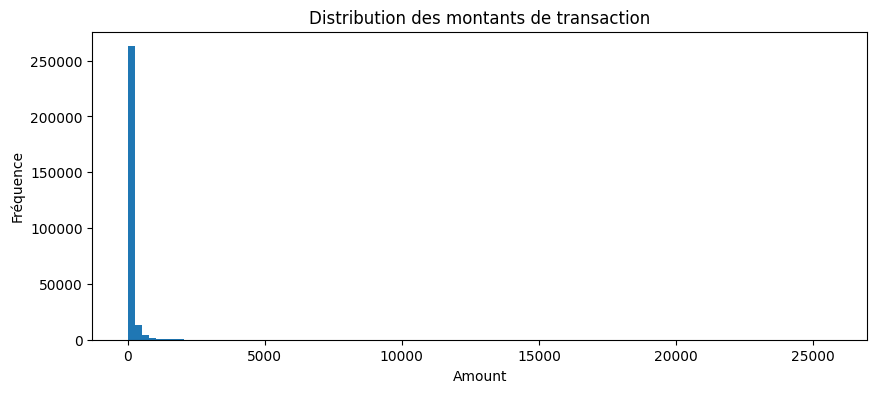

In [8]:
plt.figure(figsize=(10,4))
plt.hist(df['Amount'], bins=100)
plt.title('Distribution des montants de transaction')
plt.xlabel('Amount')
plt.ylabel('Fréquence')
plt.show()

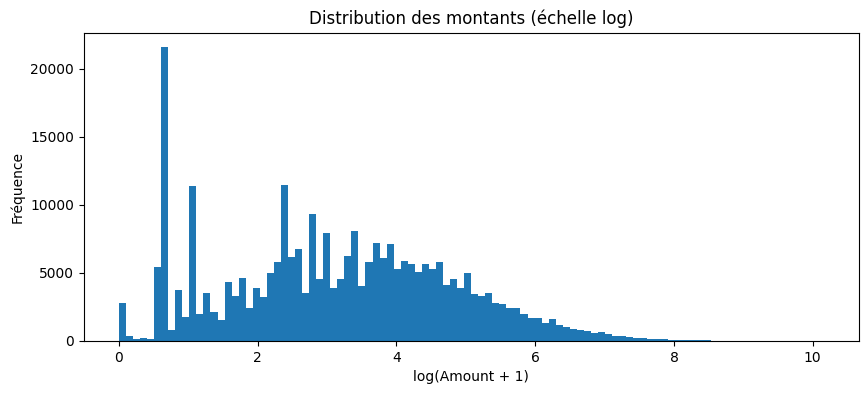

In [9]:


plt.figure(figsize=(10,4))
plt.hist(np.log1p(df['Amount']), bins=100)
plt.title('Distribution des montants (échelle log)')
plt.xlabel('log(Amount + 1)')
plt.ylabel('Fréquence')
plt.show()

# 5) Analyse bivariée (vs Class)

In [10]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


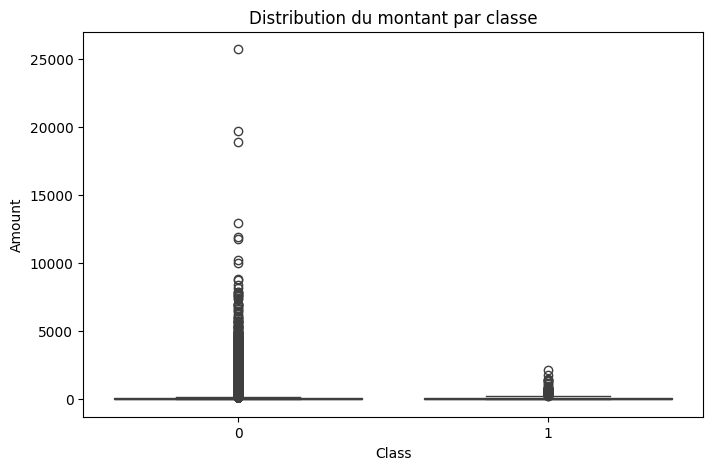

In [11]:


plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Distribution du montant par classe')
plt.show()

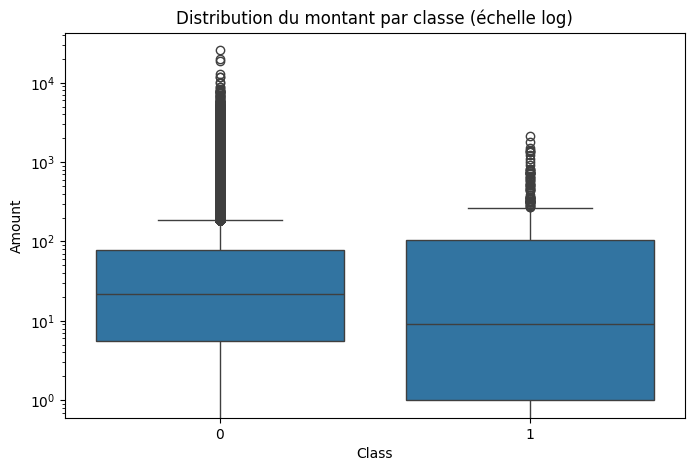

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.yscale('log')
plt.title('Distribution du montant par classe (échelle log)')
plt.show()

**Observation** : la médiane du montant des fraudes (Class=1) est inférieure à celle
des transactions normales (Class=0), avec une dispersion (IQR) plus large. Les boîtes
sont clairement séparées, ce qui suggère que `Amount` est une variable discriminante
pour la détection de fraude. Le nombre plus élevé d'outliers côté "normal" s'explique
principalement par le déséquilibre des effectifs (284 315 vs 492) plutôt que par un
vrai signal métier.

# 6) Analyse Temporelle

In [13]:
df['Hour'] = (df['Time'] // 3600) % 24

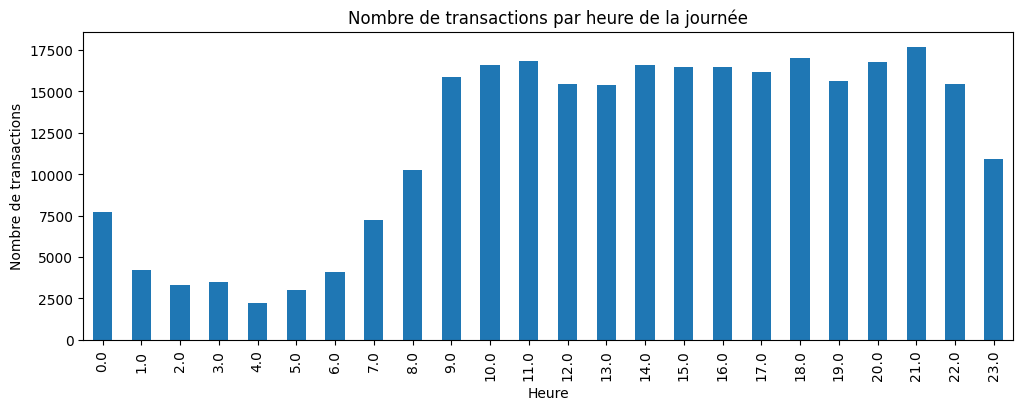

In [14]:
plt.figure(figsize=(12,4))
df['Hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Nombre de transactions par heure de la journée')
plt.xlabel('Heure')
plt.ylabel('Nombre de transactions')
plt.show()

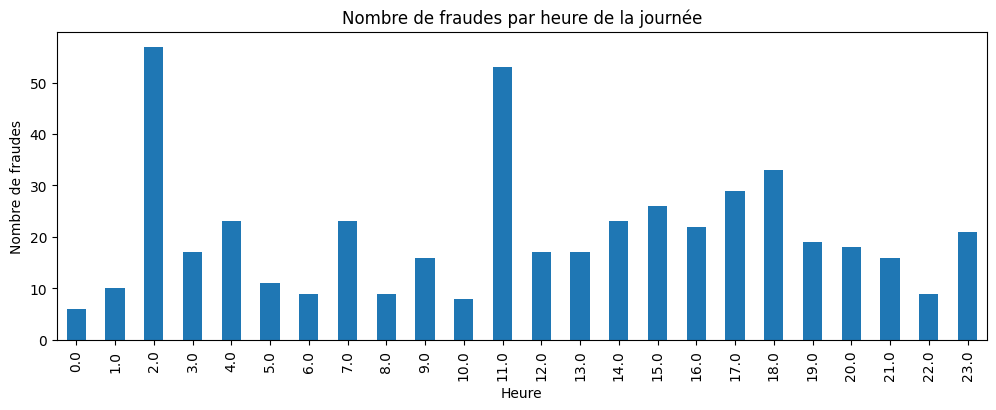

In [15]:
plt.figure(figsize=(12,4))
df[df['Class']==1]['Hour'].value_counts().sort_index().plot(kind='bar')
plt.title('Nombre de fraudes par heure de la journée')
plt.xlabel('Heure')
plt.ylabel('Nombre de fraudes')
plt.show()

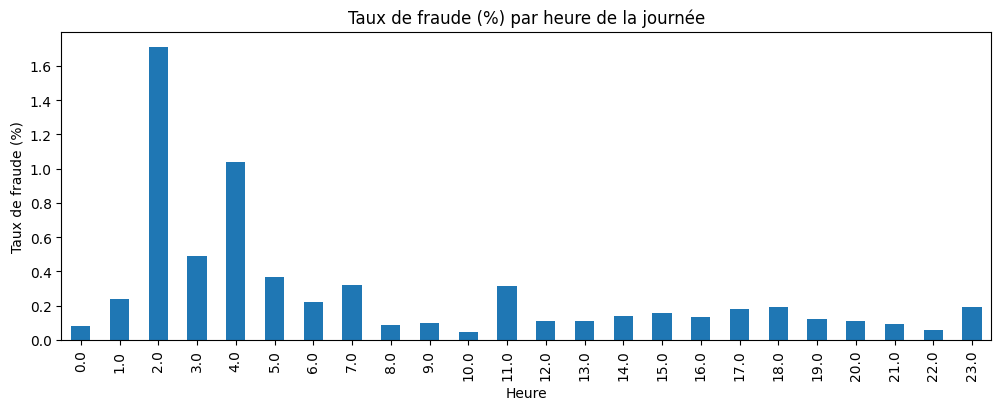

In [16]:
fraud_rate_by_hour = df.groupby('Hour')['Class'].mean() * 100

plt.figure(figsize=(12,4))
fraud_rate_by_hour.plot(kind='bar')
plt.title('Taux de fraude (%) par heure de la journée')
plt.xlabel('Heure')
plt.ylabel('Taux de fraude (%)')
plt.show()

**Observation** : le volume de transactions suit un rythme humain classique (creux
1h-8h, activité en journée). Le comptage brut de fraudes par heure est trompeur car
il ne tient pas compte du volume total variable. En taux de fraude (fraudes/total
par heure), les heures 2h et 4h ressortent nettement (>1.6% et 1%), soit ~9-10x le
taux moyen (0.17%) — les fraudeurs semblent surreprésentés pendant les heures
creuses nocturnes. `Hour` (ou une variable dérivée `is_night`) est donc une feature
candidate pertinente pour l'étape 3.

# 7) Correlations avec les features V

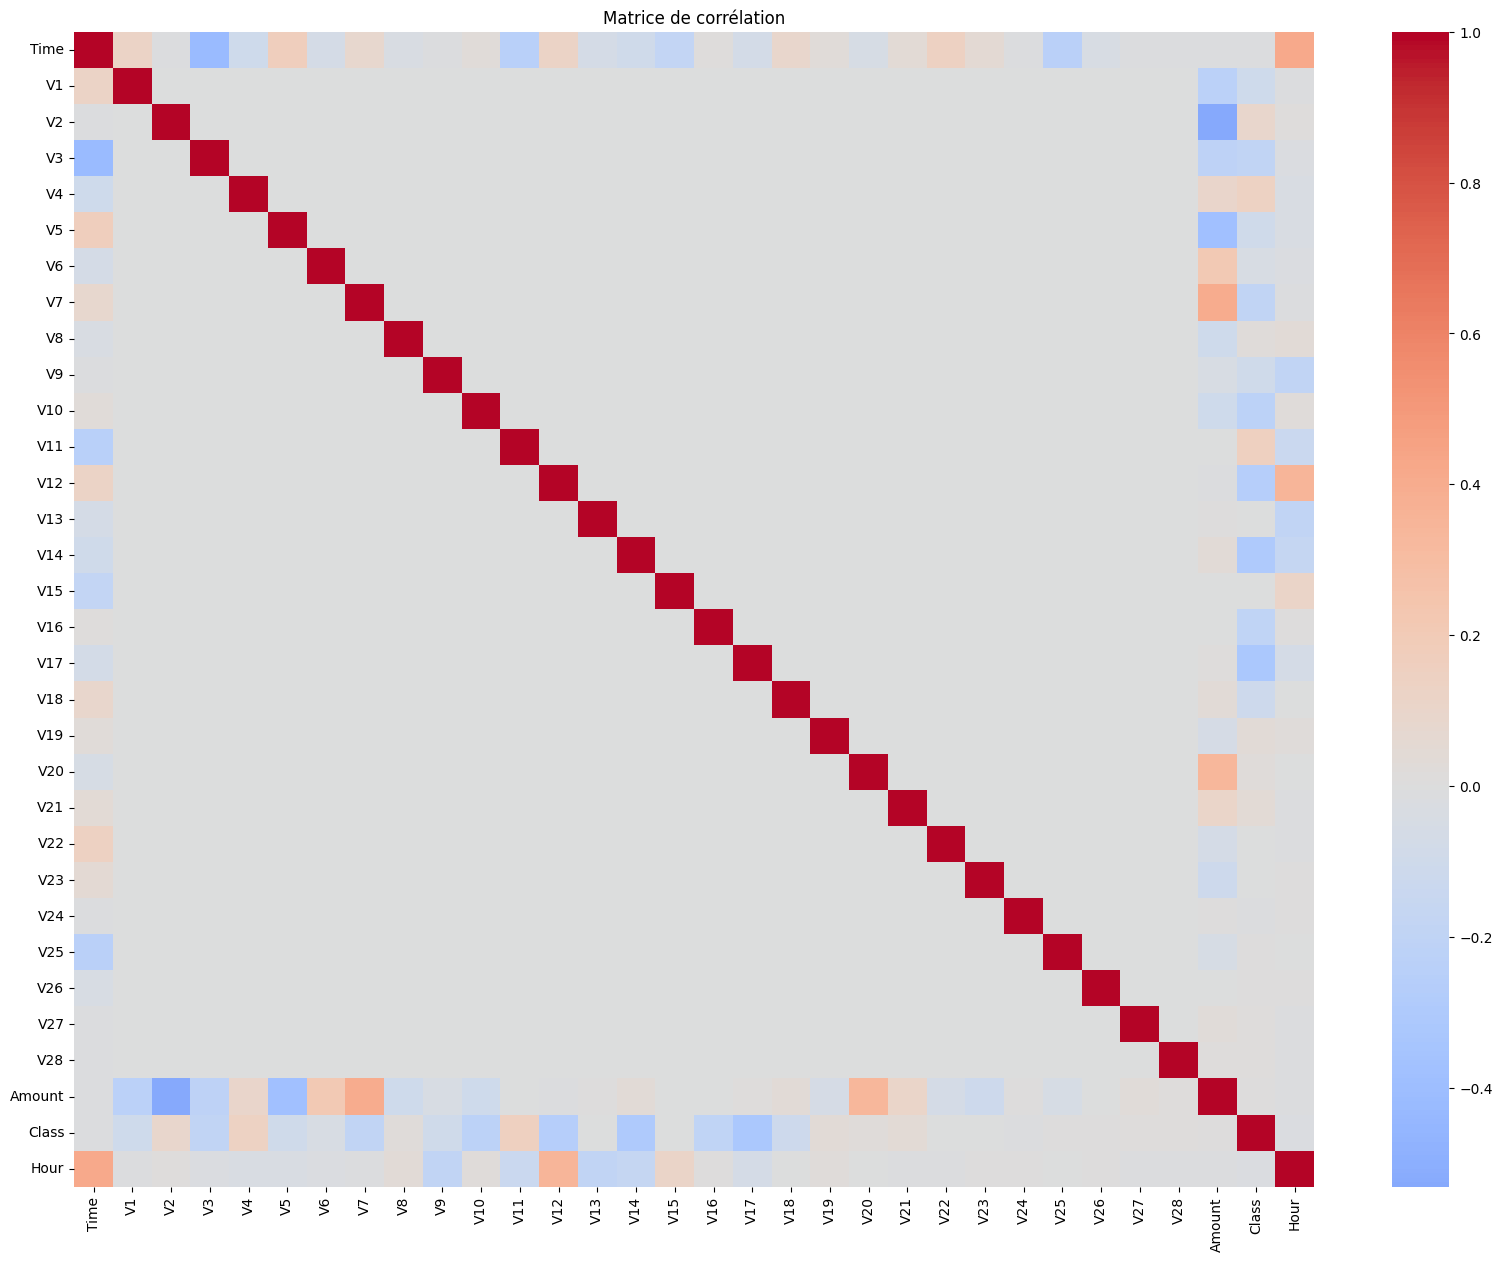

In [17]:
plt.figure(figsize=(20,15))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.show()

In [18]:
corr['Class'].sort_values(ascending=False)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
Hour     -0.017109
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

**Observation** : les variables V17, V14, V12, V10, V16, V3, V7 (corrélation négative,
jusqu'à -0.33) et V11, V4, V2 (corrélation positive, jusqu'à 0.15) sont les plus
linéairement liées à Class — bonnes candidates pour le modèle. Amount et Hour montrent
une corrélation linéaire quasi nulle malgré des signaux non-linéaires détectés plus tôt
(médiane différente, pic horaire) — rappel que la corrélation de Pearson ne capture que
les relations linéaires, pas les différences de distribution ou les patterns localisés.

# 8)Détection d'outliers

In [19]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Bornes : [{lower_bound:.2f}, {upper_bound:.2f}]")

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]
print(f"Nombre d'outliers : {len(outliers)}")
print(f"Pourcentage du dataset : {len(outliers) / len(df) * 100:.2f}%")

Bornes : [-101.75, 184.51]
Nombre d'outliers : 31904
Pourcentage du dataset : 11.20%


In [20]:
outliers['Class'].value_counts(normalize=True) * 100

Class
0    99.714769
1     0.285231
Name: proportion, dtype: float64

**Observation** : la règle IQR classique (×1.5) classe 11.20% du dataset comme
"outlier" sur Amount — un taux élevé qui s'explique par la forte asymétrie de la
distribution plutôt que par de véritables anomalies ; ces outliers ne seront pas
supprimés. Le taux de fraude parmi ces outliers (0.285%) est ~1.65x le taux moyen
(0.173%), signal modeste mais cohérent avec la dispersion plus large observée pour
Amount chez les fraudes (section 5).

# 9. Synthèse de l'EDA

### Constats clés

1. **Déséquilibre extrême des classes** : 99.83% transactions normales vs 0.17%
   fraudes (492 fraudes sur 284 807 transactions). L'accuracy seule sera une
   métrique trompeuse — nécessitera SMOTE/class weighting et un focus sur
   precision/recall/F2 plutôt qu'accuracy (étape 4).

2. **Dataset propre** : aucune valeur manquante, couvre bien 2 jours (~172 792
   secondes) comme attendu.

3. **Amount fortement asymétrique** (mean=88.35€ >> médiane=22€), avec des
   outliers jusqu'à 25 691€. Nécessitera une transformation (ex: log(Amount+1))
   pour les modèles sensibles à l'échelle.

4. **Amount est discriminant entre fraude et normal** : médiane des fraudes plus
   basse, mais dispersion (IQR) plus large — comportement plus hétérogène chez
   les fraudeurs. Cohérent avec le fait que les outliers de montant élevé ont un
   taux de fraude ~1.65x supérieur à la moyenne (0.285% vs 0.173%).

5. **Pattern temporel identifié** : le taux de fraude (pas le volume brut, qui
   est trompeur) atteint un pic à 2h-4h du matin (>1.6% et 1%, soit ~9-10x le
   taux moyen), pendant les heures creuses de trafic légitime — les fraudeurs
   semblent profiter des heures de faible surveillance.

6. **Variables les plus corrélées linéairement à Class** : négativement — V17
   (-0.33), V14 (-0.30), V12 (-0.26), V10 (-0.22), V16, V3, V7 ; positivement —
   V11 (0.15), V4 (0.13), V2 (0.09). Rappel : Amount et Hour ont une corrélation
   linéaire quasi nulle malgré des signaux réels détectés — la corrélation de
   Pearson ne capture pas les relations non-linéaires ni les patterns localisés.

### Implications pour l'étape 3 (feature engineering)

- Créer `log(Amount + 1)` pour compresser l'asymétrie
- Garder/exploiter `Hour` (déjà créée) et envisager une feature binaire
  `is_night` (ex: 0h-6h) pour capturer le pic de fraude nocturne
- Envisager une feature de fréquence/récence de transaction si des identifiants
  client étaient disponibles (non applicable ici, dataset anonymisé sans ID
  client) — à documenter comme limite du dataset
- V17, V14, V12, V10, V16, V3, V7, V11, V4, V2 sont des candidates fortes pour
  l'importance des features en modeling

### Implications pour l'étape 4 (modeling)

- Gestion du déséquilibre obligatoire (SMOTE et/ou class_weight)
- Privilégier un modèle capable de capter des relations non-linéaires
  (XGBoost) plutôt que de se fier uniquement aux corrélations linéaires
- Évaluer avec courbe precision-recall plutôt que viser precision>90% et
  recall>95% indépendamment (objectifs potentiellement opposés)